# Titanic Dataset - Exploratory Data Analysis

## Internship Task

This notebook performs basic Exploratory Data Analysis (EDA) on the Titanic dataset.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
print("Categorical:", df.select_dtypes(include='object').columns.tolist())

Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


C:\Users\Admin\AppData\Local\Temp\ipykernel_1068\688917511.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical:", df.select_dtypes(include='object').columns.tolist())


In [9]:
print("Numerical:", df.select_dtypes(include=np.number).columns.tolist())

Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


## EDA Summary(Data Story)
The Titanic dataset has 891 rows and 12 columns, each row representing one passenger. The dataset includes both numerical and cateorical/text features. Age, Cabin, and Embarked contain missing values, with Cabin missing the most. Numerical columns include Age, Fare, SibSp, and Parch; categorical columns include Sex, Embarked, and Pclass. Average passenger age is around 29-30 years, and overall survival rate is about 38%. The dataset will need cleaning (especially Age and Cabin) before it's ready for modeling.

## Task 2: Clean & Visualize Real-World Data

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Handling Missing Values

The Age column contains missing numerical values, so I filled them using the median because it is less affected by extreme values.

The Embarked column contains Only 2 categorical missing values, so I filled them using the mode.

The Cabin column contains a large number of missing values, Nearly 77%, making imputation unreliable. so I dropped this column from the dataset.

This approach helps preserve most of the available data while reducing the effect of missing values.

The cleaned dataset can now be used for visualization and further analysis.

# Detect Outliers with a Boxplot

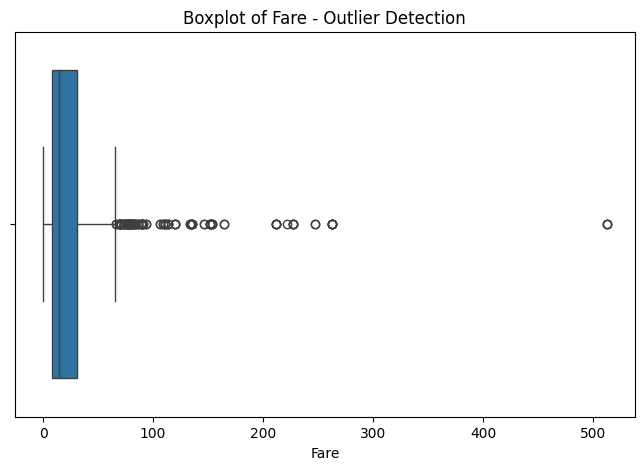

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

### Outlier Observation

The boxplot of `Fare` shows several values that are much higher than the typical passenger fare. These extreme values can be considered potential outliers. They may represent passengers who paid unusually high fares, possibly because they were traveling in higher passenger classes.

## Visualization 1 — Histogram

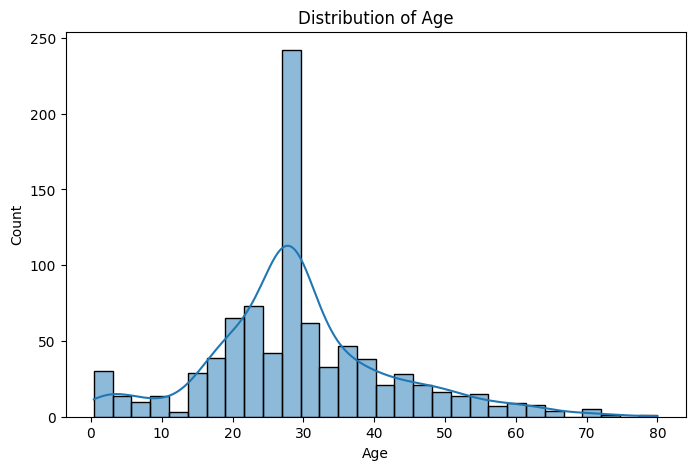

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

## Visualization 2 — Boxplot

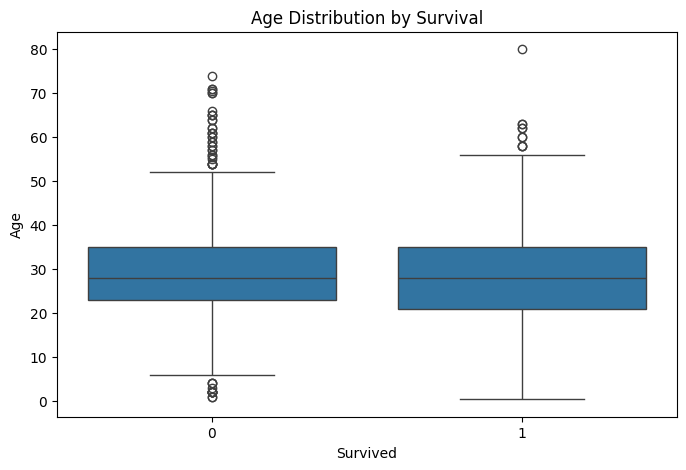

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

## Visualization 3 — Bar Chart

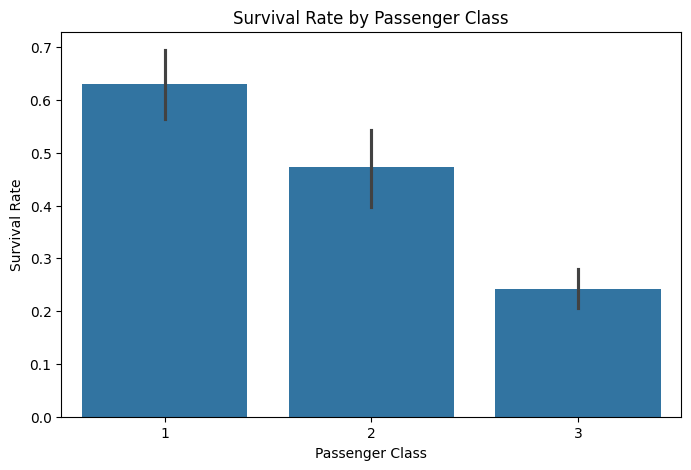

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## Visualization 4 — Correlation Heatmap

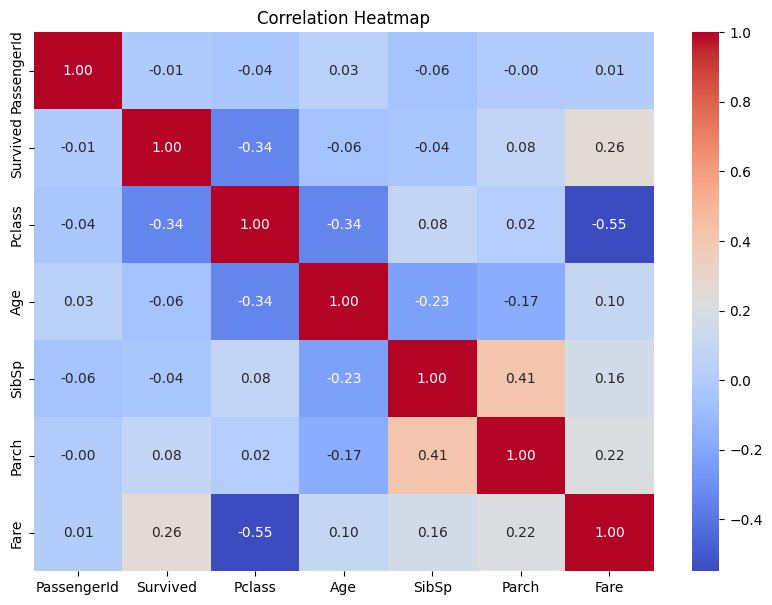

In [18]:
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Which Feature Most Affects Survival?

Based on the correlation heatmap and bar chart, Pclass (passenger class) seems to have the strongest relationship with survival. 1st class passengers had a much higher chance of surviving than 3rd class passengers. This may be because they had better access to lifeboats and were closer to the upper deck. Sex is also an important factor. It is not shown in the numeric heatmap because it is a categorical feature, but women had a much higher survival rate than men, partly because of the “women and children first” evacuation rule.

In [19]:
survival_rate = df.groupby("Sex")["Survived"].mean()

print("Survival Rate by Gender:")
print(survival_rate)

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
